## Import Data

In [ ]:
import  pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [2]:
df = pd.read_csv(r"D:\Downloads\Elevvo_Projects\Titanic-Dataset.csv")

In [3]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Clean Data

In [6]:
df['Age'] = df['Age'].fillna(df['Age'].median)               # Filling the blank rows

In [7]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])              # Filling the blanks

In [8]:
df.drop(columns= ['Cabin'],inplace=True)

### Checking Null after cleaning

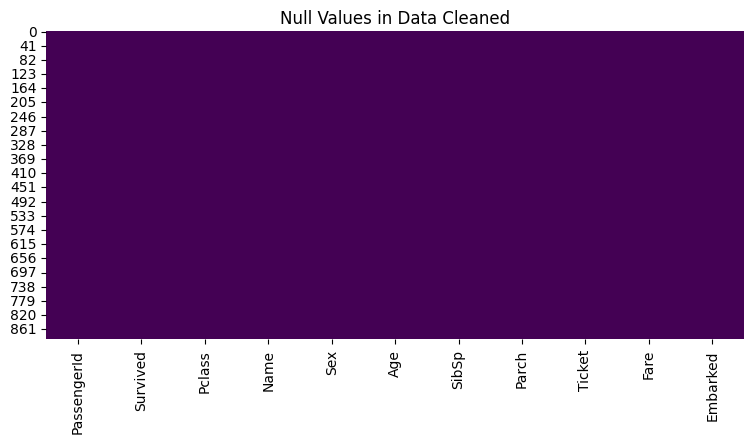

In [9]:
plt.figure(figsize=(9,4))
sns.heatmap(df.isnull(),cbar= False, cmap = 'viridis')
plt.title('Null Values in Data Cleaned')
plt.show();

### How much people survived?

In [10]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

C:\Users\hmmuz\AppData\Local\Temp\ipykernel_15612\3245550497.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Survived", data = df, palette = 'Set1')


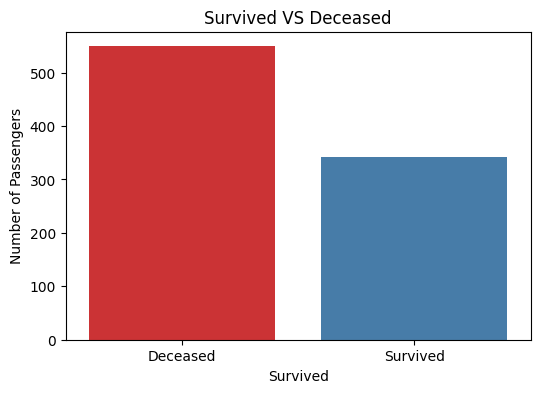

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x="Survived", data = df, palette = 'Set1')
plt.xticks([0,1],['Deceased','Survived'])
plt.title('Survived VS Deceased')
plt.ylabel('Number of Passengers') 
plt.show();

### Survival by Gender

C:\Users\hmmuz\AppData\Local\Temp\ipykernel_15612\3279120021.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = 'Sex', y = 'Survived', data = df, palette = 'muted')


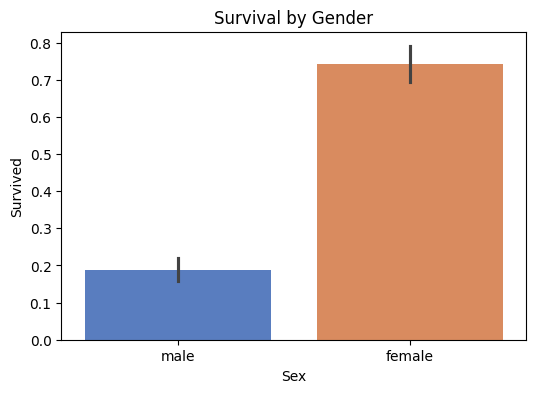

In [20]:
g_survival = df.groupby('Sex')['Survived'].mean()
plt.figure(figsize=(6,4))
sns.barplot(x = 'Sex', y = 'Survived', data = df, palette = 'muted')
plt.title('Survival by Gender')
plt.show();

### Survival by Class

C:\Users\hmmuz\AppData\Local\Temp\ipykernel_15612\4091698362.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x ='Pclass',y ='Survived', data = df, palette = 'viridis')


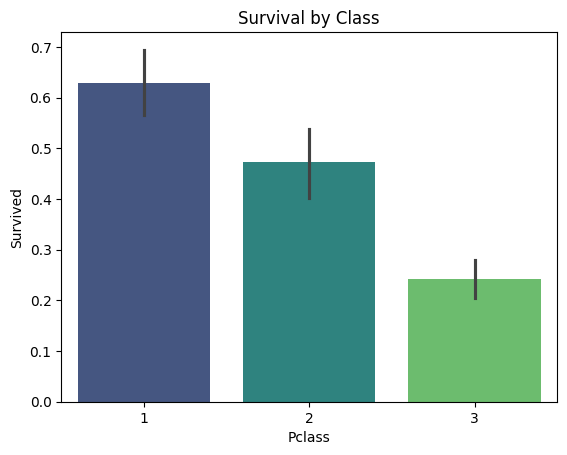

In [22]:
df.groupby('Pclass')['Survived'].mean()
sns.barplot(x ='Pclass',y ='Survived', data = df, palette = 'viridis')
plt.title('Survival by Class')
plt.show();

### Age distribution

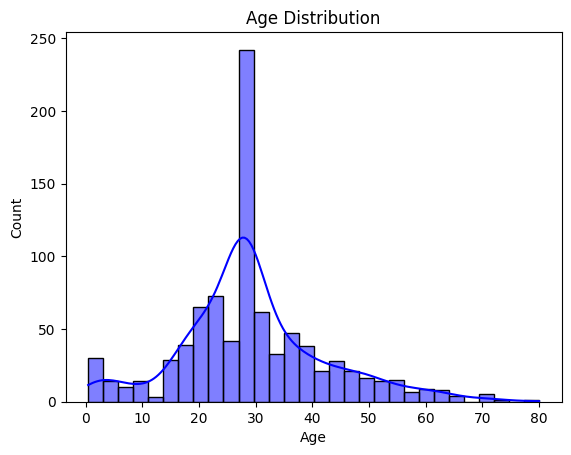

In [28]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Age'] = df['Age'].fillna(df['Age'].median())
sns.histplot(data=df, x='Age', bins= 30,kde=True, color = 'blue')
plt.title('Age Distribution')
plt.show();

### Fare Vs Survival

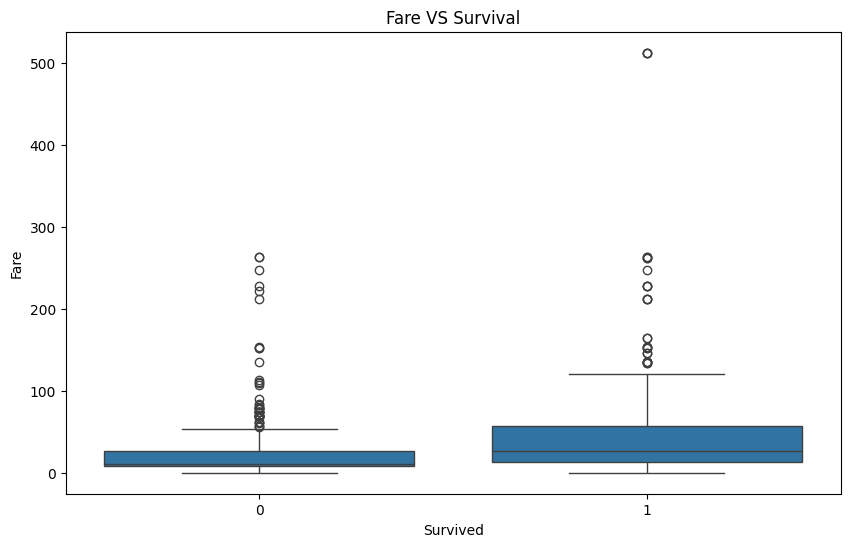

In [29]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Survived', y = 'Fare', data = df)
plt.title('Fare VS Survival')
plt.show();

### Family size VS Survival

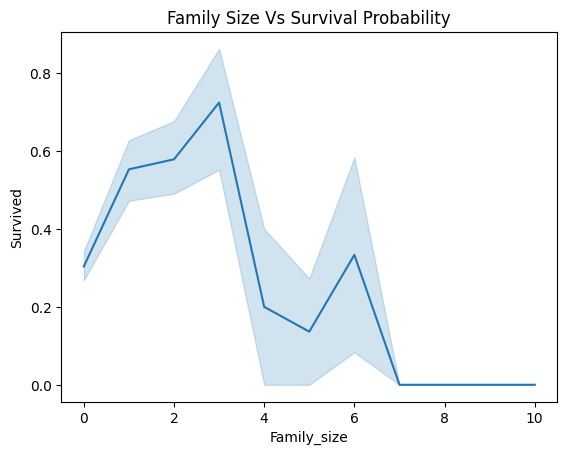

In [31]:
df['Family_size'] = df['SibSp']+df['Parch']
sns.lineplot(x='Family_size',y='Survived',data = df)
plt.title('Family Size Vs Survival Probability')
plt.show();

### Embarked impact on Survival

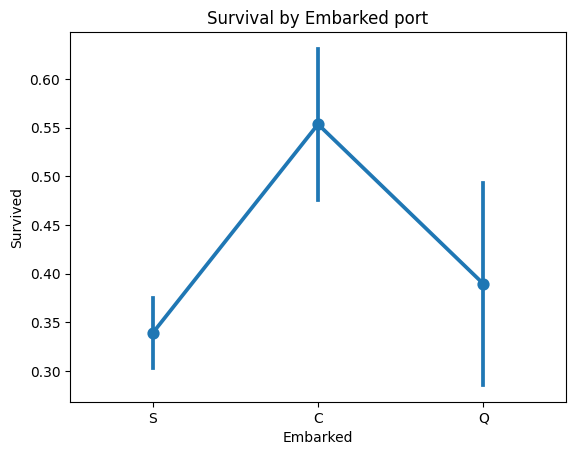

In [34]:
sns.pointplot(x='Embarked',y='Survived',data=df)
plt.title('Survival by Embarked port')
plt.show();

### Find Numeric Correlations

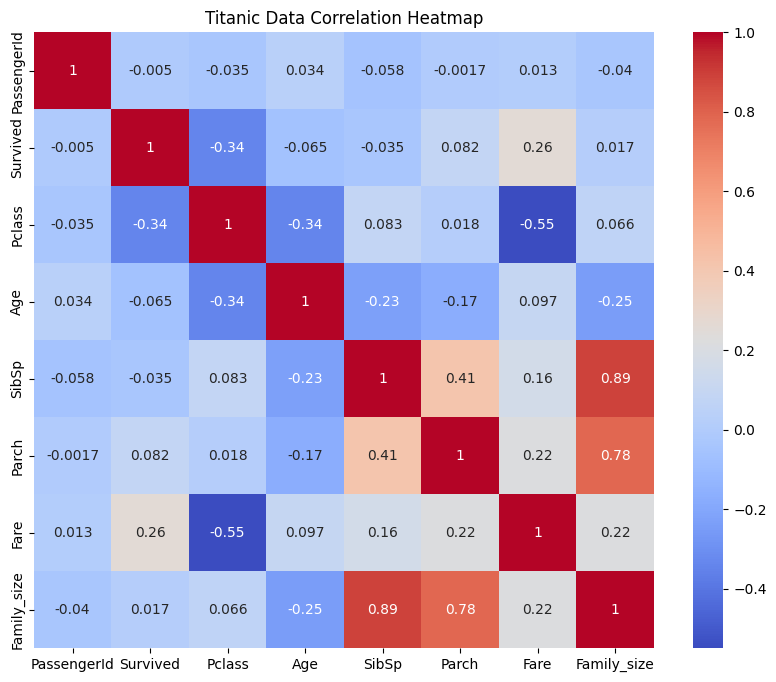

In [37]:
numeric_data = df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title('Titanic Data Correlation Heatmap')
plt.show()

## Prepare ML model

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

### Feature Selection & Encoding

In [40]:
df_ml = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']].copy()
df_ml = pd.get_dummies(df_ml, columns=['Sex', 'Embarked'], drop_first=True)

In [41]:
X = df_ml.drop('Survived', axis=1) # Input data
y = df_ml['Survived']             # Target (0 or 1)

### Train-Test Split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Model Training

In [43]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Predictions & Accuracy

In [44]:
predictions = model.predict(X_test)
score = accuracy_score(y_test, predictions)

print(f"Model Accuracy: {score * 100:.2f}%")

Model Accuracy: 81.01%


### Confusion Matrix

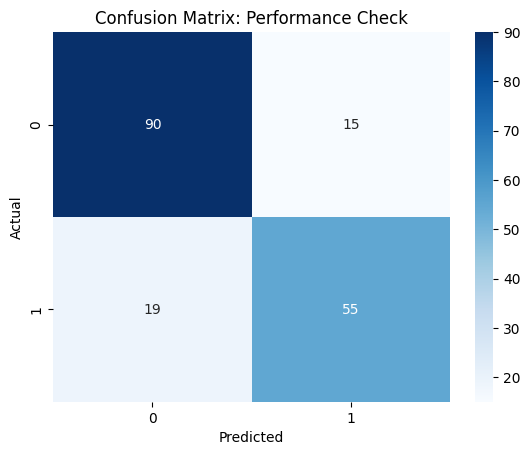

In [45]:
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Performance Check')
plt.show()

#### The confusion matrix reveals that the Logistic Regression model is particularly strong at identifying deceased passengers, though it occasionally misclassifies survivors due to the high variance in the 'Age' and 'Fare' features.